**Đề tài: Trực quan hóa chỉ số thị trường tiền mã hóa (Dựa trên mô hình CRIX) để phân tích xu hướng dòng tiền**

Để bắt đầu đồ án, chúng ta cần cài đặt và sử dụng thư viện yfinance. Đây là một mã nguồn mở (Open-source library) cực kỳ phổ biến, đóng vai trò như một "cầu nối" giúp chúng ta truy cập trực tiếp vào kho dữ liệu khổng lồ của Yahoo Finance.

Thông qua công cụ này, chúng ta sẽ thực hiện một yêu cầu tự động (Request) để tải về dữ liệu lịch sử (Historical data) của 10 đồng tiền mã hóa hàng đầu. Các thông số được ưu tiên trích xuất bao gồm:

Giá đóng cửa (Close price): Để xác định giá trị của đồng coin vào cuối ngày.

Khối lượng giao dịch (Volume): Để đo lường sức mạnh của dòng tiền (Money flow) đổ vào mỗi dự án.

**DANH SÁCH 10 ĐỒNG COIN:**

BTC (Bitcoin): Đóng vai trò là tài sản lưu trữ giá trị (store of value).

ETH (Ethereum): Nền tảng hàng đầu cho các hợp đồng thông minh (smart contracts) và ứng dụng phi tập trung (dApps).

BNB (Binance Coin): Đồng coin hệ sinh thái của sàn giao dịch (exchange-based token) lớn nhất thế giới.

SOL (Solana): Đại diện cho các mạng lưới có tốc độ giao dịch cực nhanh và chi phí thấp (high-performance blockchain).

XRP (Ripple): Đồng coin chuyên dụng cho việc thanh toán và chuyển tiền xuyên biên giới (cross-border payments).

ADA (Cardano): Nền tảng blockchain tập trung vào tính khoa học và sự bền vững (sustainability).

AVAX (Avalanche): Một đối thủ nặng ký trong mảng tài chính phi tập trung (DeFi) với khả năng mở rộng cao (scalability).

DOGE (Dogecoin): Đại diện cho nhóm "Meme coin" nhưng có vốn hóa (market cap) và cộng đồng cực kỳ lớn.

DOT (Polkadot): Giải pháp kết nối các chuỗi khối khác nhau lại với nhau (interoperability).

TRX (TRON): Nền tảng mạnh về mảng giải trí và chia sẻ nội dung số (digital content sharing).

In [169]:
%pip install -q yfinance nbformat
%pip install --upgrade kaleido

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


**LẤY DỮ LIỆU TRONG VÒNG 4 NĂM**

In [170]:
import yfinance as yf
import pandas as pd

# 1. Danh sách coin
coins = ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'XRP-USD',
         'ADA-USD', 'AVAX-USD', 'DOGE-USD', 'DOT-USD', 'TRX-USD']

final_df = pd.DataFrame()

print("🚀 Đang kéo dữ liệu về...")

for symbol in coins:
    try:
        print(f"Đang lấy: {symbol}...", end="")

        data = yf.download(
            symbol,
            start="2022-01-05",
            end="2026-01-06",
            progress=False
        )

        # ⚠️ Kiểm tra dữ liệu
        if data is None or data.empty:
            print(" -> ❌ Không có dữ liệu!")
            continue

        name = symbol.split('-')[0].lower()

        # 2. Chỉ lấy Close + Volume
        df_coin = data[['Close', 'Volume']].copy()

        # ⚠️ ĐỔI TÊN CHUẨN
        df_coin.rename(columns={
            'Close': f'{name}_price',
            'Volume': f'{name}_volume'
        }, inplace=True)

        # ⚠️ dùng join (đúng)
        if final_df.empty:
            final_df = df_coin
        else:
            final_df = final_df.join(df_coin, how='outer')

        print(" -> ✅ Xong!")

    except Exception as e:
        print(f" -> ❌ Lỗi: {e}")

# 3. Xử lý index
final_df.index = pd.to_datetime(final_df.index)
final_df = final_df.sort_index()

# 4. Xử lý missing
final_df = final_df.ffill()

# 5. Reset index
final_df.reset_index(inplace=True)
final_df.rename(columns={'index': 'Date'}, inplace=True)

print("\n🔥 KẾT QUẢ:")
display(final_df.head())

# 6. Lưu file gốc (CHƯA xử lý)
final_df.to_csv("crypto_2026.csv", index=False)

print("\n✅ Đã lưu file chuẩn: crypto_2026.csv")

🚀 Đang kéo dữ liệu về...
Đang lấy: BTC-USD... -> ✅ Xong!
Đang lấy: ETH-USD... -> ✅ Xong!
Đang lấy: BNB-USD... -> ✅ Xong!
Đang lấy: SOL-USD... -> ✅ Xong!
Đang lấy: XRP-USD... -> ✅ Xong!
Đang lấy: ADA-USD... -> ✅ Xong!
Đang lấy: AVAX-USD... -> ✅ Xong!
Đang lấy: DOGE-USD... -> ✅ Xong!
Đang lấy: DOT-USD... -> ✅ Xong!
Đang lấy: TRX-USD... -> ✅ Xong!

🔥 KẾT QUẢ:


Price,Date,btc_price,btc_volume,eth_price,eth_volume,bnb_price,bnb_volume,sol_price,sol_volume,xrp_price,...,ada_price,ada_volume,avax_price,avax_volume,doge_price,doge_volume,dot_price,dot_volume,trx_price,trx_volume
Ticker,,BTC-USD,BTC-USD,ETH-USD,ETH-USD,BNB-USD,BNB-USD,SOL-USD,SOL-USD,XRP-USD,...,ADA-USD,ADA-USD,AVAX-USD,AVAX-USD,DOGE-USD,DOGE-USD,DOT-USD,DOT-USD,TRX-USD,TRX-USD
0,2022-01-05,43569.003906,36851084859,3550.386963,18061338502,475.056946,2870757788,155.099731,2123759721,0.774358,...,1.236002,1416139355,97.852577,1168896098,0.159420,994086848,26.796141,1721841153,0.071382,1548312023
1,2022-01-06,43160.929688,30208048289,3418.408203,24293791313,473.275604,4400228627,150.431351,2097172620,0.781346,...,1.279782,1559075484,95.198540,909261500,0.160213,715345645,26.760822,1444988536,0.071112,1852557542
2,2022-01-07,41557.902344,84196607520,3193.210449,24494179209,447.788483,4613172287,136.402817,2926269672,0.763074,...,1.211547,1751707653,86.767715,1163318424,0.155023,969384523,24.925240,2764194355,0.068126,1606695992
3,2022-01-08,41733.941406,28066355845,3091.972656,16037732700,430.246155,4068139021,142.513458,2730000333,0.747688,...,1.187512,1499054949,84.056839,1021954391,0.151954,584437036,24.029129,1546276235,0.065722,1054607408
4,2022-01-09,41911.601562,21294384372,3157.751465,12334683863,438.803070,3347862691,140.839005,1599123912,0.754505,...,1.173860,1088569809,89.206558,900030318,0.151065,408786249,24.627319,1328484247,0.066267,888640481



✅ Đã lưu file chuẩn: crypto_2026.csv


**CHỈNH SỬA DỮ LIỆU**

In [171]:
import pandas as pd

# 1. Load file gốc
df = pd.read_csv('crypto_2026.csv')

# 2. Xác định cột
vol_cols = [col for col in df.columns if 'volume' in col]
price_cols = [col for col in df.columns if 'price' in col]

# 3. Ép kiểu số
for col in vol_cols + price_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Thay vì chỉ dropna chung chung, hãy reset lại index cho đẹp luôn
df.dropna(how='all', inplace=True) # Xóa các dòng trống hoàn toàn
df.dropna(inplace=True)           # Xóa các dòng có chứa bất kỳ ô NaN nào
df.reset_index(drop=True, inplace=True) # Đánh số lại từ 0 cho chuẩn

# 5. CHỈ xử lý volume (đúng chỗ)
df[vol_cols] = df[vol_cols] / 1_000_000

# (Optional) làm tròn volume
df[vol_cols] = df[vol_cols].round(2)

# 6. Đổi tên cột volume
new_names = {col: col.replace('volume', 'vol_M') for col in vol_cols}
df.rename(columns=new_names, inplace=True)

# 7. Lưu file sạch
df.to_csv('crypto_2026_clean.csv', index=False)

print("✅ Đã lưu file sạch chuẩn!")
display(df.head())

✅ Đã lưu file sạch chuẩn!


,Date,btc_price,btc_vol_M,eth_price,eth_vol_M,bnb_price,bnb_vol_M,sol_price,sol_vol_M,xrp_price,...,ada_price,ada_vol_M,avax_price,avax_vol_M,doge_price,doge_vol_M,dot_price,dot_vol_M,trx_price,trx_vol_M
0,2022-01-05,43569.003906,36851.08,3550.386963,18061.34,475.056946,2870.76,155.099731,2123.76,0.774358,...,1.236002,1416.14,97.852577,1168.90,0.159420,994.09,26.796141,1721.84,0.071382,1548.31
1,2022-01-06,43160.929688,30208.05,3418.408203,24293.79,473.275604,4400.23,150.431351,2097.17,0.781346,...,1.279782,1559.08,95.198540,909.26,0.160213,715.35,26.760822,1444.99,0.071112,1852.56
2,2022-01-07,41557.902344,84196.61,3193.210449,24494.18,447.788483,4613.17,136.402817,2926.27,0.763074,...,1.211547,1751.71,86.767715,1163.32,0.155023,969.38,24.925240,2764.19,0.068126,1606.70
3,2022-01-08,41733.941406,28066.36,3091.972656,16037.73,430.246155,4068.14,142.513458,2730.00,0.747688,...,1.187512,1499.05,84.056839,1021.95,0.151954,584.44,24.029129,1546.28,0.065722,1054.61
4,2022-01-09,41911.601562,21294.38,3157.751465,12334.68,438.803070,3347.86,140.839005,1599.12,0.754505,...,1.173860,1088.57,89.206558,900.03,0.151065,408.79,24.627319,1328.48,0.066267,888.64


**NẠP DỮ LIỆU VÀ CHUẨN BỊ**

In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Đọc dữ liệu
df = pd.read_csv('crypto_2026_clean.csv')

# ⚠️ FIX: đảm bảo Date đúng kiểu datetime
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Xác định cột
price_cols = [c for c in df.columns if 'price' in c.lower()]
vol_cols = [c for c in df.columns if 'vol' in c.lower()]

print("✅ Đã nạp dữ liệu và xác định các cột thành công!")

✅ Đã nạp dữ liệu và xác định các cột thành công!


**TÍNH TỔNG KHỐI LƯỢNG GIAO DỊCH**

In [173]:
# Tính tổng khối lượng giao dịch của cả 10 đồng mỗi ngày
df['Total_Volume'] = df[vol_cols].sum(axis=1)

# Hiển thị kết quả
df[['Total_Volume']].head()

,Total_Volume
Date,
2022-01-05,69008.95
2022-01-06,69645.50
2022-01-07,126815.15
2022-01-08,58400.65
2022-01-09,44373.05


### Tính tổng khối lượng giao dịch (Total Volume)

Tổng khối lượng giao dịch mỗi ngày được tính bằng cách cộng khối lượng giao dịch của tất cả các đồng tiền mã hóa trong danh mục.

Cụ thể, `df[vol_cols].sum(axis=1)` thực hiện phép cộng theo từng hàng (tức là theo từng ngày), từ đó tạo ra một cột mới `Total_Volume` đại diện cho tổng dòng tiền giao dịch của toàn thị trường trong ngày đó.

Giá trị này giúp phản ánh mức độ hoạt động và thanh khoản của thị trường theo thời gian.

**TÍNH SIMPLE RETURNS**

In [174]:
import numpy as np

# Đảm bảo datetime index
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
elif not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

# Cột giá
price_cols = [c for c in df.columns if 'price' in c]

# PERCENTAGE RETURNS
returns = df[price_cols].pct_change().fillna(0)

# Xóa dòng đầu
# returns = returns.dropna()  # fillna(0) đã xử lý dòng đầu

print("✅ Returns summary:")
print(returns.describe())

display(returns.head())

✅ Returns summary:
         btc_price    eth_price    bnb_price    sol_price    xrp_price  \
count  1462.000000  1462.000000  1462.000000  1462.000000  1462.000000   
mean      0.000887     0.000600     0.000903     0.001228     0.001715   
std       0.026922     0.036539     0.030201     0.050925     0.045467   
min      -0.159747    -0.174564    -0.185654    -0.422809    -0.195181   
25%      -0.011312    -0.017383    -0.013148    -0.028034    -0.017916   
50%      -0.000008     0.000187     0.001079    -0.000949     0.000023   
75%       0.013126     0.017382     0.014830     0.027546     0.017138   
max       0.145412     0.217988     0.172340     0.325944     0.730750   

         ada_price   avax_price   doge_price    dot_price    trx_price  
count  1462.000000  1462.000000  1462.000000  1462.000000  1462.000000  
mean      0.000320    -0.000053     0.001138    -0.000782     0.001512  
std       0.047123     0.049932     0.048893     0.042890     0.036153  
min      -0.242796    

,btc_price,eth_price,bnb_price,sol_price,xrp_price,ada_price,avax_price,doge_price,dot_price,trx_price
Date,,,,,,,,,,
2022-01-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-06,-0.009366,-0.037173,-0.003750,-0.030099,0.009024,0.035421,-0.027123,0.004974,-0.001318,-0.003782
2022-01-07,-0.037141,-0.065878,-0.053853,-0.093255,-0.023385,-0.053318,-0.088560,-0.032394,-0.068592,-0.041990
2022-01-08,0.004236,-0.031704,-0.039175,0.044798,-0.020163,-0.019838,-0.031243,-0.019797,-0.035952,-0.035288
2022-01-09,0.004257,0.021274,0.019888,-0.011749,0.009117,-0.011496,0.061265,-0.005850,0.024894,0.008292


# Phân tích: Simple Returns (Lợi suất phần trăm)

Trong phân tích dữ liệu tài chính và mô hình đo lường rủi ro như CRIX, việc đo lường biến động giá hàng ngày là rất quan trọng. **Simple Returns (Lợi suất phần trăm hay Lợi suất đơn)** là một trong những thước đo phổ biến và dễ hiểu nhất để đánh giá hiệu suất của một tài sản.

### 1. Công thức toán học
Lợi suất phần trăm được tính bằng cách lấy sự thay đổi về giá giữa ngày hôm nay và ngày hôm qua chia cho giá của ngày hôm qua:

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

*(Trong đó: $P_t$ là giá ngày hiện tại, $P_{t-1}$ là giá ngày trước đó)*

### 2. Triển khai code (Python/Pandas)
Trong Python, chúng ta có thể sử dụng trực tiếp hàm `.pct_change()` được tích hợp sẵn của thư viện `pandas`. Hàm này sẽ tự động tính toán tỷ lệ phần trăm thay đổi so với dòng ngay trước đó:

`returns = df[price_cols].pct_change().fillna(0)`

*(Lưu ý: Chúng ta dùng `.fillna(0)` để gán lợi suất của ngày đầu tiên trong chuỗi dữ liệu bằng 0 thay vì báo lỗi NaN).*

### 3. Tại sao mô hình này sử dụng Simple Returns?
* **Dễ hiểu và trực quan:** Simple Returns phản ánh chính xác tỷ lệ sinh lời thực tế mà một nhà đầu tư nhận được. Ví dụ: Nếu bạn mua tài sản ở giá 100$ và bán ở giá 105$, lợi suất phần trăm của bạn là đúng 5%.
* **Tính toán danh mục (Portfolio Additivity):** Không giống như Log Returns, Simple Returns cho phép tính toán dễ dàng lợi suất của một danh mục đầu tư bằng cách lấy tổng có trọng số (weighted sum) lợi suất của các tài sản thành phần. Tính chất này đặc biệt phù hợp với việc xây dựng chỉ số theo trọng số khối lượng như CRIX.

### 4. Ví dụ trong dataset (Bitcoin ngày 06/01 - 07/01/2022)
Trích xuất dữ liệu giá trị thực tế của Bitcoin trong 2 ngày 06/01/2022 và 07/01/2022:
* Giá đóng cửa ngày 06/01/2022: **$43,160.93**
* Giá đóng cửa ngày 07/01/2022: **$41,557.90**

**Áp dụng công thức tính Simple Return cho ngày 07/01/2022:**
$$r = \frac{41557.90 - 43160.93}{43160.93} = \frac{-1603.03}{43160.93} \approx \textbf{-0.037141}$$

> **Kết luận:** Con số `-0.037141` chính là giá trị lợi suất được ghi nhận vào tập dữ liệu `returns` của ngày 07/01/2022. Nó đại diện cho mức sụt giảm xấp xỉ 3.71% của Bitcoin trong ngày hôm đó so với ngày trước đó.

**TÍNH WEIGHT RETURNS (THEO VOLUME)**

In [175]:
# Tính tổng volume mỗi ngày
total_vol = df[vol_cols].sum(axis=1)

# Tính weight matrix
weights = df[vol_cols].div(total_vol, axis=0)

# Đổi tên cột weight cho khớp returns
weights.columns = [col.replace('vol_M', 'price') for col in weights.columns]

# Tính weighted returns
weighted_returns = (weights * returns).sum(axis=1)

# Xem kết quả
weighted_returns.head()

Date
2022-01-05    0.000000
2022-01-06   -0.017530
2022-01-07   -0.045747
2022-01-08   -0.010767
2022-01-09    0.011095
dtype: float64

### Tính tỷ suất sinh lời có trọng số (Volume-Weighted Returns)

Trong bước này, tỷ suất sinh lời của từng đồng tiền được kết hợp lại thành một giá trị duy nhất cho toàn thị trường, dựa trên trọng số là khối lượng giao dịch (volume).

Cụ thể, tại mỗi thời điểm, trọng số của một tài sản được tính bằng:

$$
w_{i,t} = \frac{Volume_{i,t}}{Total\ Volume_t}
$$

Sau đó, tỷ suất sinh lời có trọng số của thị trường được tính bằng:

$$
r_t = \sum_{i=1}^{n} w_{i,t} \cdot r_{i,t}
$$

---

### Ví dụ tính toán (ngày 07/01/2022)

Dựa trên dataset:

- **Tổng volume ngày 07/01/2022**:
$$
Total\ Volume = 126815.15
$$

---

####  Bitcoin (BTC)

- Volume = 84196.61
- Simple Returns = -0.037141  

Trọng số:

$$
w_{BTC} = \frac{84196.61}{126815.15} \approx 0.664
$$

Đóng góp vào thị trường:

$$
0.664 \times -0.037141 \approx -0.024662
$$

---

####  Ethereum (ETH)

- Volume = 24494.18  
- Simple Returns = -0.065878	  

Trọng số:

$$
w_{ETH} = \frac{24494.18}{126815.15} \approx 0.193
$$

Đóng góp:

$$
0.193 \times -0.065878 \approx -0.012714
$$

---

####  Tổng hợp

Các coin còn lại cũng được tính tương tự và cộng vào:

$$
r_t = \sum w_i \cdot r_i
$$

Kết quả cuối cùng:

$$
r_t \approx -0.045747
$$

---

### Kết quả

| Ngày       | Weighted Return |
|------------|-----------------|
| 2022-01-07 | -0.045747        |

$$
r_t = -0.045747 = -4.57\%
$$

 Điều này cho thấy: **toàn bộ thị trường crypto đã giảm khoảng 4.57% trong ngày 07/01/2022**, sau khi đã xét đến mức độ ảnh hưởng của từng đồng coin dựa trên khối lượng giao dịch.

---

### Kết luận

Phương pháp này phản ánh dòng tiền thực tế, trong đó các tài sản có khối lượng giao dịch lớn (như BTC, ETH) sẽ có ảnh hưởng mạnh hơn đến chỉ số chung. Do đó, chỉ số CRIX được xây dựng từ weighted return sẽ phản ánh chính xác hơn xu hướng của toàn thị trường.

**TÍNH CHỈ SỐ CRIX VÀ HIỂN THỊ BIỂU ĐỒ**

✅ KẾT QUẢ TÍNH TOÁN CHỈ SỐ CRIX (5 NGÀY ĐẦU & 5 NGÀY CUỐI):


,Date,CRIX
0,2022-01-05,1000.000000
1,2022-01-06,982.470015
2,2022-01-07,937.524751
3,2022-01-08,927.430068
4,2022-01-09,937.719697


...


,Date,CRIX
1457,2026-01-01,6849.904665
1458,2026-01-02,7059.120408
1459,2026-01-03,7094.801172
1460,2026-01-04,7174.483619
1461,2026-01-05,7411.266412


--------------------------------------------------


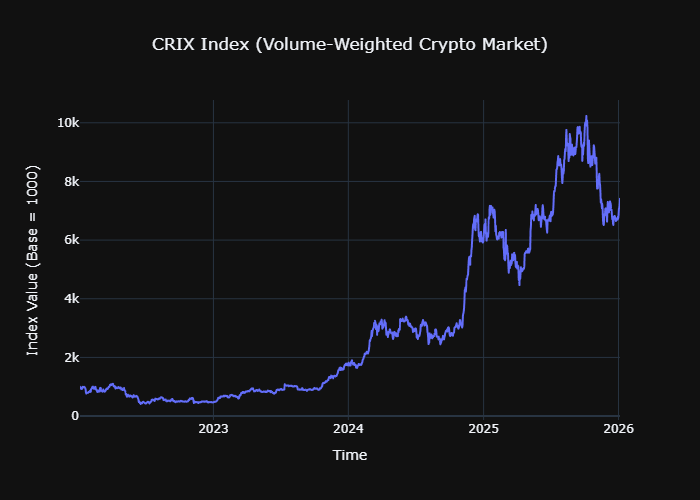

In [176]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png"
from IPython.display import display

# ===== 1. Đọc dữ liệu =====
df = pd.read_csv('crypto_2026_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# ===== 2. Tự động lấy cột =====
price_cols = [c for c in df.columns if 'price' in c.lower()]
vol_cols = [c for c in df.columns if 'vol' in c.lower()]

# ===== 3. Tổng Volume =====
df['Total_Volume'] = df[vol_cols].sum(axis=1)

# ===== 4. LOG RETURN =====
returns = df[price_cols].pct_change().fillna(0)

# ===== 5. WEIGHTED RETURNS =====
weighted_returns = pd.Series(0.0, index=returns.index)

for v_col in vol_cols:
    p_col = v_col.replace('vol_M', 'price').replace('volume', 'price')

    weight = (
        df[v_col] /
        df['Total_Volume']
    )

    weighted_returns += weight * returns[p_col]

# ===== 6. CRIX =====
crix = [1000.0]

for r in weighted_returns.iloc[1:]:
    crix.append(crix[-1] * (1 + r))

df['CRIX'] = crix

# ===== 7. RESET INDEX để plot =====
df_plot = df[['CRIX']].dropna().reset_index()

# =======================================================
# ===== 7.5. HIỂN THỊ KẾT QUẢ CHỈ SỐ CRIX ====
# =======================================================
print("✅ KẾT QUẢ TÍNH TOÁN CHỈ SỐ CRIX (5 NGÀY ĐẦU & 5 NGÀY CUỐI):")

display(df_plot.head())
print("...")
display(df_plot.tail())
print("-" * 50)

# ===== 8. PLOTLY VISUALIZATION =====
fig = px.line(
    df_plot,
    x='Date',
    y='CRIX',
    title='CRIX Index (Volume-Weighted Crypto Market)',
    labels={'CRIX': 'Index Value (Base = 1000)', 'Date': 'Time'}
)

# Tăng độ đẹp
fig.update_layout(
    template='plotly_dark',   # nền tối nhìn chuyên nghiệp
    title_x=0.5,              # căn giữa title
    hovermode='x unified'     # hover 1 điểm cho toàn bộ
)

fig.show()

### Ví dụ: Tính CRIX cho ngày 06/01/2022
Chúng ta sẽ lấy số liệu thực tế từ dataset của ngày **05/01/2022** và **06/01/2022**. Để dễ hiểu, ví dụ này sẽ trình bày chi tiết cho 2 đồng chiếm tỷ trọng lớn nhất (BTC và ETH), các đồng còn lại thuật toán tính hoàn toàn tương tự.

**Dữ liệu thực tế ngày 06/01/2022:**
* **Tổng dòng tiền thị trường (Total Volume 10 đồng):** **69,645.50 M$** (Triệu USD)
* **Bitcoin (BTC):**
  * Giá ngày 05: $43,569.00
  * Giá ngày 06: $43,160.93
  * Volume ngày 06: **30,208.05 M$**
* **Ethereum (ETH):**
  * Giá ngày 05: $3,550.39
  * Giá ngày 06: $3,418.41
  * Volume ngày 06: **24,293.79 M$**
* **Điểm CRIX khởi điểm (05/01/2022):** **1000.00 điểm**.

---

#### Bước 1: Tính Lợi suất đơn ($r$) cho từng đồng
Áp dụng công thức Lợi suất phần trăm: $r = \frac{P_{t} - P_{t-1}}{P_{t-1}}$
* **Lợi suất BTC ($r_{BTC}$):** $\frac{43160.93 - 43569.00}{43569.00} \approx \textbf{-0.009366}$ (Giảm ~0.94%)
* **Lợi suất ETH ($r_{ETH}$):** $\frac{3418.41 - 3550.39}{3550.39} \approx \textbf{-0.037173}$ (Giảm ~3.72%)

#### Bước 2: Tính Trọng số dòng tiền ($W$)
Khối lượng giao dịch (Volume) quyết định "trọng lượng" của đồng coin đó trong chỉ số:
* **Trọng số BTC ($W_{BTC}$):** $30208.05 / 69645.50 \approx \textbf{0.4337}$ (Chiếm 43.37% toàn thị trường)
* **Trọng số ETH ($W_{ETH}$):** $24293.79 / 69645.50 \approx \textbf{0.3488}$ (Chiếm 34.88% toàn thị trường)

#### Bước 3: Tính Lợi suất chung của thị trường ($R_m$)
Nhân trọng số với lợi suất của từng đồng rồi cộng lại (thuật toán tính cho cả 10 đồng):
$$
R_m = (W_{BTC} \times r_{BTC}) + (W_{ETH} \times r_{ETH}) + \dots + (W_{TRX} \times r_{TRX})
$$
$$
R_m = (0.4337 \times -0.009366) + (0.3488 \times -0.037173) + \dots (\text{8 đồng kia})
$$
*(Thuật toán Python sau khi quét qua cả 10 đồng sẽ cho ra Lợi suất chung của toàn thị trường ngày 06/01 là **$R_m = -0.017530$**)*

#### Bước 4: Cập nhật điểm số CRIX
Sử dụng công thức lợi suất đơn để cập nhật Điểm CRIX:
$$
\text{CRIX}_{06/01} = \text{CRIX}_{05/01} \times (1 + R_m)
$$
$$
\text{CRIX}_{06/01} = 1000 \times (1 - 0.017530)
$$
$$
\text{CRIX}_{06/01} \approx 1000 \times 0.982470 \approx \textbf{982.47}
$$

> **Kết luận Insight:** Dựa vào số liệu thực tế, vào ngày 06/01/2022, mặc dù giá BTC chỉ giảm nhẹ 0.94%, nhưng ETH giảm mạnh 3.72% kết hợp cùng các Altcoin khác đi xuống đã kéo chỉ số chung đi xuống. Tổng hợp lại theo trọng số khối lượng, toàn thị trường đã khiến chỉ số CRIX sụt giảm từ **1000** xuống **982.47 điểm** (giảm khoảng 1.75% chỉ sau 1 ngày).

* **Xu hướng tổng thể:** Thị trường biến động cực mạnh (high volatility). Chỉ số có sự tăng trưởng bùng nổ trong suốt giai đoạn 2023 - 2025 và đạt đỉnh vào tháng 10/2025 trước khi điều chỉnh giảm vào cuối năm.
* **Vùng đáy (Tháng 6/2022):** Chỉ số rơi xuống mức thấp nhất lịch sử là **411.36 điểm** ngày 18/06/2022, phản ánh giai đoạn ảm đạm của thị trường (mùa đông crypto).
* **Đỉnh cao nhất (06/10/2025):** Đạt mức **10,231.62 điểm** (tăng gấp hơn 10 lần so với mức cơ sở 1000). Đây là giai đoạn thị trường hưng phấn nhất (euphoria).
* **Nhịp điều chỉnh (Tháng 11/2025):** Xuất hiện cú rơi tự do từ đỉnh khi chỉ số sụt giảm về mức **6,513.64 điểm** vào ngày 22/11/2025.
* **Kết luận:** Biểu đồ cho thấy tính chu kỳ (cyclicality) rất nhanh của thị trường Crypto: CRIX mất gần 4 năm để tích lũy tạo đỉnh nhưng có thể sụt giảm hơn 36% chỉ trong vòng chưa đầy 2 tháng.

### Phân tích: Sự phân bổ dòng tiền giữa các đồng coin (2022 - 2026)

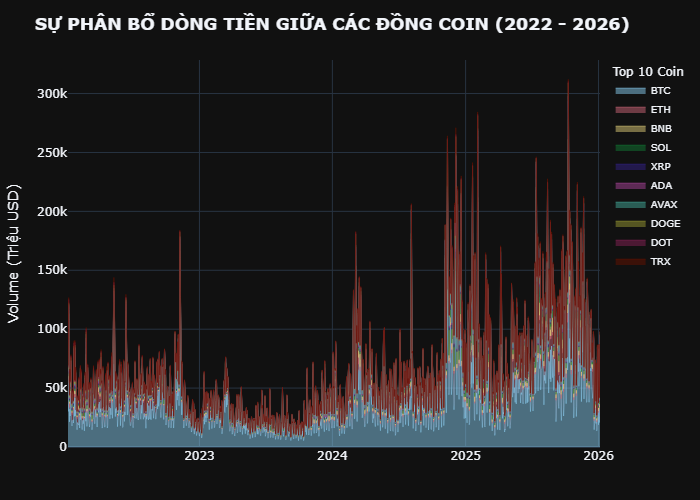

In [177]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png"

# 1. Nạp dữ liệu 1 năm sạch sẽ
df = pd.read_csv('crypto_2026_clean.csv')

# Đảm bảo Date là kiểu thời gian và làm trục index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Lấy ra danh sách các cột Volume (giờ nó tên là vol_M rồi)
vol_cols = [col for col in df.columns if 'vol_M' in col]

# =========================================================
# =========================================================

# Lấy dữ liệu Volume và chuẩn hóa tên
df_vol_plot = df[vol_cols].copy()
df_vol_plot.columns = [c.split('_')[0].upper() for c in vol_cols]

# Đảm bảo dữ liệu theo thứ tự thời gian
df_vol_plot = df_vol_plot.sort_index()

# Vẽ biểu đồ Vùng (Area)
fig2 = px.area(
    df_vol_plot,
    x=df_vol_plot.index,
    y=df_vol_plot.columns,
    title='<b>SỰ PHÂN BỔ DÒNG TIỀN GIỮA CÁC ĐỒNG COIN (2022 - 2026)</b>',
    color_discrete_sequence=px.colors.qualitative.Safe, # Giữ nguyên hệ màu Safe
    labels={"value": "Volume (Triệu USD)", "variable": "Coin"}
)

fig2.update_layout(
    template='plotly_dark',
    xaxis_title='',
    yaxis_title='Volume (Triệu USD)',
    legend_title='Top 10 Coin',
    hovermode='x unified',
    legend=dict(
        font=dict(size=10),
        itemclick="toggleothers", # Click đúp vào 1 coin để ẩn hết mấy con khác
    ),
    margin=dict(l=40, r=40, t=60, b=40)
)

# Làm mịn đường + hover (hiệu ứng khi lướt chuột) đẹp hơn
fig2.update_traces(
    line=dict(width=0.5),
    hovertemplate='%{fullData.name}: %{y:,.2f} M$' # Thêm dấu phẩy ngăn cách ngàn và ký hiệu M$ cho dễ đọc
)

fig2.show()

* **Sự áp đảo của BTC và ETH:** Hai đồng tiền lớn nhất chiếm phần lớn diện tích biểu đồ, cho thấy dòng tiền tập trung cực lớn vào nhóm vốn hóa lớn (Large-cap). Tại ngày 31/12/2025, BTC đạt volume hơn **33.8 tỷ USD**, ETH hơn **16.4 tỷ USD**.
* **Tính đồng bộ của thị trường:** Các cột sóng khối lượng (Volume spikes) xuất hiện đồng đều ở tất cả các đồng coin (đặc biệt là các đợt bùng nổ thanh khoản chung). Điều này chứng tỏ tâm lý dòng tiền thường biến động theo xu hướng chung của thị trường, dẫn dắt bởi Bitcoin.
* **Vị thế của Altcoin:** SOL và BNB duy trì vị thế dẫn đầu trong nhóm Altcoin về tính thanh khoản (Liquidity). Các đồng như DOGE, XRP, ADA chiếm tỷ trọng nhỏ hơn nhưng vẫn có những đợt bùng nổ khối lượng ngắn hạn.
* **Dòng tiền cuối năm:** Vào cuối tháng 12/2025, mặc dù khối lượng giao dịch có sụt giảm so với các đợt cao điểm trước đó, dòng tiền vẫn duy trì ổn định, tập trung chính vào BTC và ETH để trú ẩn an toàn (Safe haven).

**SO SÁNH CRIX VÀ BITCOIN**

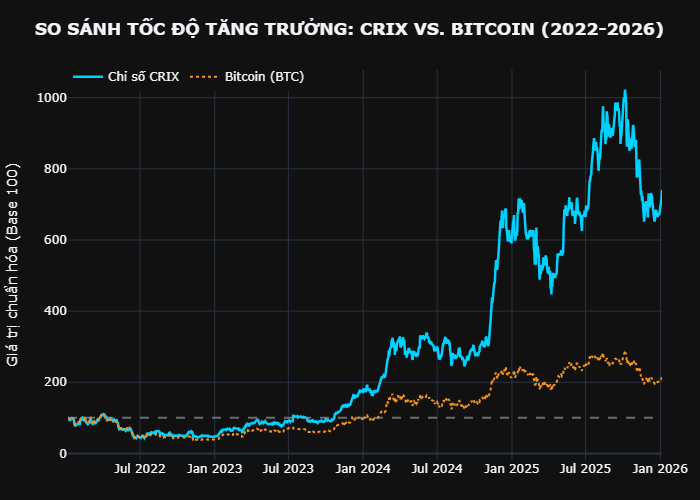

In [178]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "png"

# 1. Đảm bảo dữ liệu đã có CRIX (Tính toán lại nếu bị mất do load lại df)
price_cols = [c for c in df.columns if 'price' in c.lower()]
vol_cols = [c for c in df.columns if 'vol' in c.lower()]

if 'CRIX' not in df.columns:
    # Tính simple return
    returns_temp = df[price_cols].pct_change().fillna(0)
    # Tính tổng volume
    total_vol_temp = df[vol_cols].sum(axis=1)
    # Tính weighted returns
    weighted_returns_temp = pd.Series(0.0, index=returns_temp.index)
    for v_col in vol_cols:
        p_col = v_col.replace('vol_M', 'price')
        weight = df[v_col] / total_vol_temp
        weighted_returns_temp += weight * returns_temp[p_col]
    # Tạo cột CRIX
    crix_temp = [1000.0]
    for r in weighted_returns_temp.iloc[1:]:
        crix_temp.append(crix_temp[-1] * (1 + r))
    df['CRIX'] = crix_temp

# 2. Chuẩn hóa về mốc 100 để so sánh
crix_norm = (df['CRIX'] / df['CRIX'].dropna().iloc[0]) * 100
btc_norm = (df['btc_price'] / df['btc_price'].iloc[0]) * 100

# 3. Khởi tạo biểu đồ
fig3 = go.Figure()

fig3.add_trace(go.Scatter(
    x=df.index,
    y=crix_norm,
    name='Chỉ số CRIX',
    line=dict(color='#00d2ff', width=2.5),
    hovertemplate='<b>CRIX</b>: %{y:,.2f}<extra></extra>'
))

fig3.add_trace(go.Scatter(
    x=df.index,
    y=btc_norm,
    name='Bitcoin (BTC)',
    line=dict(color='#F7931A', width=2, dash='dot'),
    hovertemplate='<b>BTC</b>: %{y:,.2f}<extra></extra>'
))

# 4. Giao diện Dark Mode
fig3.update_layout(
    title='<b>SO SÁNH TỐC ĐỘ TĂNG TRƯỞNG: CRIX VS. BITCOIN (2022-2026)</b>',
    template='plotly_dark',
    yaxis_title='Giá trị chuẩn hóa (Base 100)',
    hovermode='x unified',
    legend=dict(orientation='h', y=1.02, x=0),
    margin=dict(l=50, r=30, t=70, b=40)
)

fig3.add_hline(y=100, line_dash="dash", line_color="#8B949E", opacity=0.7)

fig3.show()


📊 **Dữ liệu gốc trước khi chuẩn hóa:**

**Ngày 05/01/2022 (Ngày đầu tiên):**
* Giá Bitcoin (BTC): **43,569.00 USD**
* Chỉ số CRIX: **1,000.00 điểm** (mốc xuất phát mặc định)

**Ngày 06/01/2022 (Ngày thứ hai):**
* Giá Bitcoin (BTC): **43,160.93 USD**
* Chỉ số CRIX: **982.47 điểm** (đã tính ở các phần trước)

Vấn đề ở đây là: hơn 43 ngàn đô và 1 ngàn điểm làm sao vẽ lên cùng một tỷ lệ để so sánh? Do đó ta cần Bước 2!

---

🧮 **Thực hiện Bước 2: Chuẩn hóa về mốc 100**

Công thức trong code: *Giá trị chuẩn hóa = (Giá trị ngày hiện tại / Giá trị ngày đầu tiên) \* 100*

**Ép Bitcoin (BTC) về mốc 100:**
* Ngày 05/01/2022: $(43,569.00 / 43,569.00) \times 100 = \textbf{100}$
* Ngày 06/01/2022: $(43,160.93 / 43,569.00) \times 100 \approx \textbf{99.06}$
$\rightarrow$ Nghĩa là sang ngày thứ hai, BTC đạt mức **99.06 điểm** (giảm 0.94%).

**Ép Chỉ số CRIX về mốc 100:**
* Ngày 05/01/2022: $(1,000 / 1,000) \times 100 = \textbf{100}$
* Ngày 06/01/2022: $(982.47 / 1,000) \times 100 \approx \textbf{98.25}$
$\rightarrow$ Nghĩa là sang ngày thứ hai, CRIX đạt mức **98.25 điểm** (giảm 1.75%).

---

📈 **Phân tích so sánh tốc độ tăng trưởng:**

* **Tương quan (Correlation):** CRIX và BTC có xu hướng di chuyển cùng chiều rất chặt chẽ, tuy nhiên CRIX có biên độ dao động mạnh hơn (higher volatility) do ảnh hưởng từ nhóm Altcoin biến động cao.
* **Giai đoạn bùng nổ (Tháng 7 - Tháng 10/2025):** Chỉ số CRIX tăng trưởng vượt trội so với Bitcoin. Đỉnh điểm ngày 06/10/2025, CRIX (chuẩn hóa) đạt trên **1,023 điểm**, trong khi BTC chỉ đạt khoảng **286 điểm**. Điều này cho thấy các Altcoin trong rổ chỉ số đã bứt phá rất mạnh trong giai đoạn này.
* **Đặc điểm rủi ro:** CRIX lên cao hơn nhưng khi thị trường sụt giảm (sau tháng 10/2025), nó cũng lao dốc với tốc độ nhanh hơn BTC, cho thấy tính rủi ro cao hơn của danh mục đa dạng hóa khi thị trường đảo chiều.
* **Chốt năm (30/12/2025):**
  * CRIX (chuẩn hóa): **678.69** (vẫn giữ được mức tăng trưởng vượt bậc so với đầu năm 2022).
  * BTC (chuẩn hóa): **202.97** (tăng gấp đôi so với mức khởi điểm).
* **Kết luận:** Trong suốt giai đoạn từ 2022 đến 2026, đầu tư theo chỉ số thị trường (CRIX) mang lại hiệu suất tốt hơn là chỉ nắm giữ Bitcoin đơn thuần, dù phải chịu biến động mạnh hơn.

**TỶ TRỌNG DÒNG TIỀN CỦA CÁC ĐỒNG COIN**

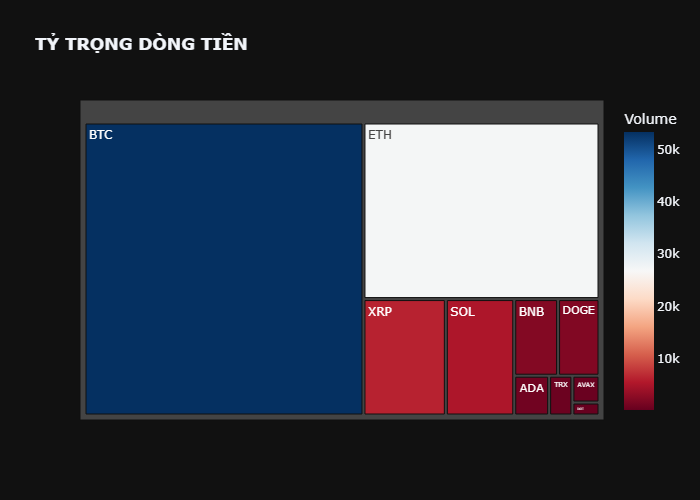

In [179]:
import plotly.express as px
import pandas as pd
import plotly.io as pio
pio.renderers.default = "png"

# Nạp dữ liệu sạch sẽ của ông (đã xử lý trước đó)
df = pd.read_csv('crypto_2026_clean.csv')
# Lấy dữ liệu ngày cuối cùng để xem cơ cấu hiện tại
latest_data = df_vol_plot.iloc[-1].reset_index()
latest_data.columns = ['Coin', 'Volume']

fig4 = px.treemap(latest_data, path=['Coin'], values='Volume',
                  title='<b>TỶ TRỌNG DÒNG TIỀN </b>',
                  color='Volume', color_continuous_scale='RdBu')

fig4.update_layout(template='plotly_dark')
fig4.show()


* **Sự thống trị tuyệt đối của Bitcoin (BTC):** BTC chiếm diện tích lớn nhất và có màu xanh đậm nhất trên Treemap, tương ứng với khối lượng giao dịch khổng lồ (~53.4 tỷ USD vào ngày cuối cùng 05/01/2026). Điều này khẳng định BTC là "trọng tâm" điều hướng dòng tiền toàn thị trường.
* **Cấu trúc thị trường phân tầng:**
  * **Nhóm dẫn dắt:** BTC và ETH chiếm áp đảo về vốn hóa và thanh khoản (khu vực diện tích lớn màu xanh/trắng).
  * **Nhóm Altcoins:** Các đồng như SOL, BNB, XRP, DOGE... chiếm diện tích nhỏ hơn nhiều, cho thấy dòng tiền bắt đầu phân hóa mạnh khi chảy vào các lớp tài sản rủi ro hơn.
* **Tương quan màu sắc & Khối lượng:** Thang màu thể hiện rõ độ lệch thanh khoản lớn. Thị trường tập trung cực độ vào các đồng coin top đầu, tạo ra sự chênh lệch lớn về độ sâu giao dịch giữa các nhóm.
* **Insight:** Cấu trúc này cho thấy tâm lý nhà đầu tư vẫn ưu tiên sự an toàn và tính thanh khoản cao của các tài sản đầu ngành trong bối cảnh thị trường biến động.

**MA TRẬN TƯƠNG QUAN**

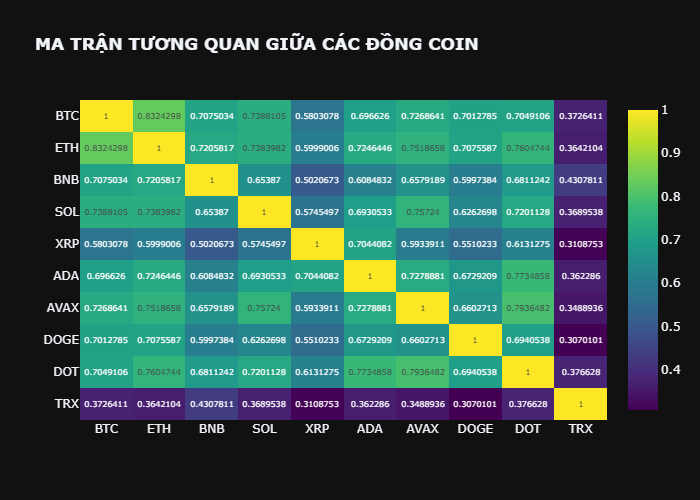

In [180]:
import seaborn as sns
import pandas as pd
import plotly.io as pio
pio.renderers.default = "png"

# Nạp dữ liệu sạch sẽ của ông (đã xử lý trước đó)
df = pd.read_csv('crypto_2026_clean.csv')
# Tính tương quan giữa tỷ suất sinh lời của 10 coin
corr = returns.corr()
# Đổi tên cột cho ngắn gọn
corr.columns = [c.split('_')[0].upper() for c in corr.columns]
corr.index = corr.columns

fig5 = px.imshow(corr, text_auto=True, aspect="auto",
                title='<b>MA TRẬN TƯƠNG QUAN GIỮA CÁC ĐỒNG COIN</b>',
                color_continuous_scale='Viridis')

fig5.update_layout(template='plotly_dark')
fig5.show()

* **Tương quan thuận mạnh (Strong Positive Correlation):** Phần lớn các đồng coin lớn đều có hệ số tương quan cao ($r > 0.6$), cho thấy chúng thường biến động cùng chiều với nhau.
  * **BTC & ETH (0.83):** Mối quan hệ cực kỳ chặt chẽ, dẫn dắt xu hướng chung.
  * **DOT & AVAX (0.79) & DOT & ADA (0.77):** Các cặp Altcoin có mức độ biến động rất đồng đều với nhau.
* **Trường hợp ngoại lệ (The Outlier):** TRX là đồng coin có hệ số tương quan thấp nhất so với mặt bằng chung ($r$ chỉ từ **0.31 - 0.43**). Điều này cho thấy TRX có xu hướng chuyển động độc lập hơn so với phần còn lại của thị trường.
* **Vùng màu sắc:** Các ô màu sáng (gần mức 1) tập trung nhiều ở nhóm Top đầu, minh chứng cho việc khi thị trường biến động mạnh, các đồng coin này sẽ chuyển động cùng hướng.
* **Insight (Nhận định):** Để đa dạng hóa danh mục (portfolio diversification) và giảm thiểu rủi ro, nhà đầu tư nên tìm kiếm các cặp có tương quan thấp (như TRX với các coin khác) thay vì dồn hết vào các cặp có tương quan quá cao.